In [75]:
import os

import torch
import torch.nn.functional as F

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy import stats

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import random

from datasets import load_from_disk
from torch.utils.data import DataLoader

from src.utils.img_encoder import ImgEncoder
from src.utils.expr_encoder import ExprEncoder
from src.utils.loss_function import contrastive_loss
from src.utils.dataset_class import Multi_Modal_Dataset

from src.utils.config import PROJECT_DIR

import optuna

# import matplotlib.pyplot as plt

In [76]:
checkpoint_path = os.path.join(PROJECT_DIR, "checkpoints", "best-epoch=68-val_loss=4.0644.ckpt")
checkpoint = torch.load(checkpoint_path, map_location="cpu")
hparams = checkpoint['hyper_parameters']

expr_encoder = ExprEncoder(
    in_dim=2000,
    hidden_dims=hparams['expr_hidden_dims'],
    out_dim=128,
    dropout_probs=hparams['expr_dropout_probs'],
    batchnorm=True # [*]
)

img_encoder = ImgEncoder(
    in_dim=2048,
    hidden_dims=hparams['img_hidden_dims'],
    out_dim=128,
    dropout_probs=hparams['img_dropout_probs'],
    batchnorm=True # [*]
)

state_dict = checkpoint['state_dict']

img_state_dict = {k.replace('img_encoder.', ''): v for k, v in state_dict.items() if k.startswith('img_encoder.')}
expr_state_dict = {k.replace('expr_encoder.', ''): v for k, v in state_dict.items() if k.startswith('expr_encoder.')}

# Load into models
img_encoder.load_state_dict(img_state_dict)
expr_encoder.load_state_dict(expr_state_dict)

img_encoder.eval()
expr_encoder.eval()

# def (img, expr, pid):
#     return img_encoder(img), expr_encoder(expr), pid
    
print("Encoder weights loaded successfully!")

Encoder weights loaded successfully!


In [77]:
arrow_dataset = load_from_disk(os.path.join(PROJECT_DIR, "data", "dataset"))
all_data = {}
with torch.no_grad():
    for k in ['train', 'valid', 'test']:
        img, expr, pid = next(iter(DataLoader(
            Multi_Modal_Dataset(arrow_dataset[k], k_patches="all"),
            batch_size=len(arrow_dataset[k])
        )))
        all_data[k+'_img'] = img
        all_data[k+'_expr'] = expr
        all_data[k+'_img_emb'] = img_encoder(img)
        all_data[k+'_expr_emb'] = expr_encoder(expr)
        all_data[k+'_pid'] = [p[:12] for p in pid]

for x in ['_img', '_expr']:
    for y in ['', '_emb']:
        all_data['dev'+x+y] = torch.cat((all_data['train'+x+y], all_data['valid'+x+y]), dim=0)
all_data['dev_pid'] = all_data['train_pid'] + all_data['valid_pid']

sims = F.cosine_similarity(
    all_data['test_img_emb'].unsqueeze(1), 
    all_data['dev_img_emb'].unsqueeze(0), 
    dim=2
)


# sanity check!
for i in range(all_data['test_img_emb'].shape[0]):
    for j in range(all_data['dev_img_emb'].shape[0]):
        assert abs(sims[i, j].item() - torch.matmul(
            F.normalize(all_data['test_img_emb'][i].unsqueeze(0), dim=1), 
            F.normalize(all_data['dev_img_emb'][j].unsqueeze(0), dim=1).T
        ).item()) < 1e-6

sorted_sims = torch.argsort(sims, dim=1, descending=True)

pid_mapping = {
    all_data['test_pid'][i]: [all_data['dev_pid'][j] for j in row.tolist()]
    for i, row in enumerate(sorted_sims)
}

In [78]:
clin_df = pd.read_csv(os.path.join(PROJECT_DIR, "data", "data_clinical_patient.txt"), sep='\t', header=None)
clin_df.columns = clin_df.iloc[4].values
clin_df = clin_df.iloc[5:].reset_index(drop=True)
clin_df['SUBTYPE'] = clin_df['SUBTYPE'].str.replace('BRCA_', '', regex=False)
pid2subtype = clin_df.set_index('PATIENT_ID')['SUBTYPE'].to_dict()

def zero_shot_subtype_classification(K):
    
    knn_subtypes = { 
        k: [pid2subtype[k]] + [pid2subtype[p] for p in v if pd.notna(pid2subtype[p])]
        for k, v in pid_mapping.items()
    }
    knn_subtypes = pd.DataFrame(knn_subtypes)
    knn_subtypes = knn_subtypes.dropna(axis=1, how='any')
    knn_subtypes = knn_subtypes.iloc[:(K+1)]

    def get_strict_majority(col):
        # 1. Get the frequency counts
        counts = col.value_counts()
        
        assert not counts.empty
        
        # 2. If there's only one unique value, it's the majority
        if len(counts) == 1:
            return counts.index[0]
        
        # 3. Compare the count of the 1st most frequent to the 2nd
        # If the 1st frequency is strictly greater than the 2nd, we have a winner
        if counts.iloc[0] > counts.iloc[1]:
            return counts.index[0]
        
        # 4. Otherwise, it's a tie (e.g., [a, b, c, b, a, c] or [a, a, b, b])
        return 'Unclassified'

    vote_subtypes = pd.concat(
        [knn_subtypes.iloc[:1], knn_subtypes.iloc[1:].agg([get_strict_majority])], 
        axis=0
    ).reset_index(drop=True)

    y_true = vote_subtypes.iloc[0].tolist()
    y_pred = vote_subtypes.iloc[1].tolist()
    
    return y_true, y_pred

/Users/sogand/miniconda3/envs/pmc-data/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/sogand/miniconda3/envs/pmc-data/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sogand/miniconda3/envs/pmc-data/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sogand/miniconda3/envs/pmc-data/lib/python3.11/site-packages/sklearn/metrics/_classifi

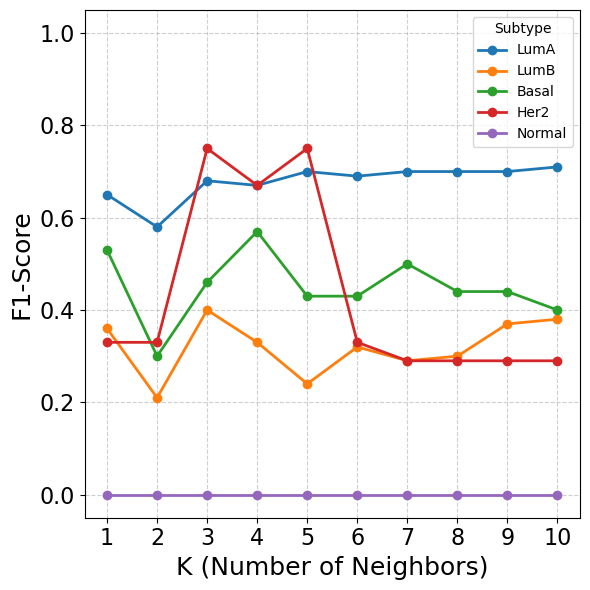

In [107]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score, 
    precision_score, recall_score, roc_auc_score, average_precision_score
)



classes = ['LumA', 'LumB', 'Basal', 'Her2', 'Normal']
results = []

for k in range(1, 11):

    


    y_true, y_pred = zero_shot_subtype_classification(k)
    classes = ['LumA', 'LumB', 'Basal', 'Her2', 'Normal', 'Unclassified']
    assert set(y_true+y_pred+['Unclassified']) == set(classes)

    le = LabelEncoder()
    le.fit(classes)


    # 2. Transform string labels to numeric
    y_true_num = le.transform(y_true)
    y_pred_num = le.transform(y_pred)
    n_classes = len(classes)

    # 1. Get the string of classification_report
    report_str = classification_report(y_true=y_true, y_pred=y_pred, labels = classes, zero_division=0)

    # print(report_str)

    metrics_row = {
        "K": k,
        "Accuracy": accuracy_score(y_true_num, y_pred_num),
        "Balanced Accuracy": balanced_accuracy_score(y_true_num, y_pred_num),
        "Macro F1": f1_score(y_true_num, y_pred_num, average='macro'),
        "Weighted F1": f1_score(y_true_num, y_pred_num, average='weighted'),
        "Macro Precision": precision_score(y_true_num, y_pred_num, average='macro'),
        "Macro Recall": recall_score(y_true_num, y_pred_num, average='macro'),
        # "Macro AUROC": roc_auc_score(
        #     y_true_num, y_pred_num, average='macro', multi_class='ovr'
        # ),
        # "Macro PR-AUC": average_precision_score(
        #     y_true_num, y_pred_num, average='macro'
        # )
    }

    # 2. Extract f1-scores for each class using regex
    # It looks for the class name and grabs the third decimal number (f1)
    k_f1s = {'K': k}
    for cls in classes:
        pattern = rf"{cls}\s+[\d.]+\s+[\d.]+\s+([\d.]+)"
        match = re.search(pattern, report_str)
        k_f1s[cls] = float(match.group(1)) if match else 0.0
  
    results.append(k_f1s)

# 3. Convert results to a DataFrame for easy plotting
df_plot = pd.DataFrame(results).set_index('K')

classes.remove('Unclassified')
df_plot = df_plot.drop('Unclassified', axis=1)

# 4. Generate the plot
plt.figure(figsize=(6, 6))
for cls in classes:
    plt.plot(df_plot.index, df_plot[cls], marker='o', label=cls, linewidth=2)

plt.tick_params(axis='both', labelsize=16)
plt.xlabel('K (Number of Neighbors)', fontsize=18)
plt.ylabel('F1-Score', fontsize=18)
plt.xticks(range(1, 11))
plt.ylim(-0.05, 1.05) # Keeps the scale consistent 0 to 1
plt.legend(title="Subtype")#, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("zeroshot_F1_scores.pdf", format='pdf', bbox_inches='tight')
plt.show()

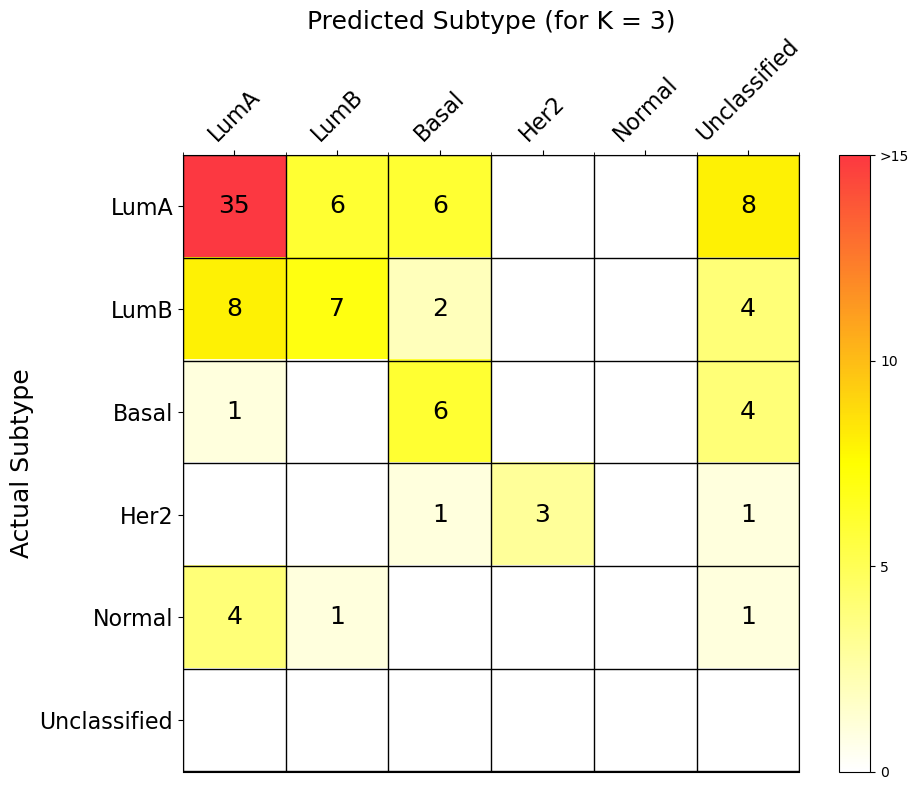

In [26]:
k = 3

y_true, y_pred = zero_shot_subtype_classification(k)

# 1. Setup labels
classes = ['LumA', 'LumB', 'Basal', 'Her2', 'Normal', 'Unclassified']
assert set(y_true+y_pred+['Unclassified']) == set(classes)

# 2. Generate matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

colors = ["#ffffff", "yellow", "#fc3841"] 
custom_cmap = LinearSegmentedColormap.from_list("white_yellow_red", colors)

mx = 15

# Plot with vmax=10 to keep contrast
disp.plot(
    cmap=custom_cmap, 
    ax=ax, 
    values_format='d', 
    im_kw={'vmax': mx}
)

# 4. INCREASE FONT SIZE of numbers within tiles
# disp.text_ contains the text objects for each cell
for i, text in enumerate(disp.text_.ravel()):
    val = cm.ravel()[i]
    if val == 0:
        text.set_text("")  # Hide the number if it is zero
    else:
        text.set_fontsize(18)
        text.set_color('black')

# 5. ADD BLACK GRID LINES between tiles
# Set minor ticks at the halfway point between labels
ax.set_xticks(np.arange(len(classes) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(classes) + 1) - 0.5, minor=True)
# Draw the grid using those minor ticks
ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
# Hide the minor tick markers themselves
ax.tick_params(which="minor", bottom=False, left=False)

# 6. Adjust Colorbar Legend for ">mx"
cbar = disp.im_.colorbar
new_ticks = list(range(0, mx+1, 5))
cbar.set_ticks(new_ticks)
cbar.set_ticklabels([str(int(t)) if t < mx else '>'+str(mx) for t in new_ticks])

# 7. Final Polish
ax.set_xlabel('Predicted Subtype (for K = '+str(k)+')', fontsize=18)
ax.set_ylabel('Actual Subtype', fontsize=18)
ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()

plt.savefig("zeroshot_Subtype_Confusion_Matrix.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [6]:
# ------------------------------------------------------------------------------------------------------------------
print("Preprocess gene expression data")

expr = pd.read_csv(os.path.join(PROJECT_DIR, "data", "data_mrna_seq_v2_rsem.txt"), sep="\t")

assert expr.shape[1] == len(set(expr.columns))
genes = expr.iloc[:, :2].copy()
expr = expr.iloc[:, 2:].copy()
expr.columns = [col[:12] for col in expr.columns]
assert expr.notna().all().all()
main_expr = expr

# extract the columns that are for training data
columns_in_train = list(set(expr.columns) & set(all_data['train_pid']))



# using training data, get the indices of the genes with >10 RSEM in >10% of samples
idx = (100 * (expr[columns_in_train] > 10).sum(axis=1) / len(columns_in_train)) > 10
# to remove lowly expressed genes, subset everything by those indices
genes = genes[idx]
expr = expr[idx]

# log1p-transform all expression data
expr = np.log1p(expr)

# calculate Mean & Standard deviation per gene across the training data
MU = expr[columns_in_train].mean(axis=1)
SD = expr[columns_in_train].std(axis=1)

# get the indices of the top 2000 most variable genes
idx = SD.sort_values(ascending=False).head(2000).index

# subset everything by those indices
genes = genes.loc[idx]
expr = expr.loc[idx]
MU = MU.loc[idx]
SD = SD.loc[idx]

# transform to z-scores using the calculated statistics
assert SD.min() > 1e-8
expr_z = expr.sub(MU, axis=0).div(SD, axis=0)
# make the list of gene identifiers (which is in the same order of rows in the data)
assert not genes['Hugo_Symbol'].astype(str).str.contains("_").any()
assert not genes['Entrez_Gene_Id'].astype(str).str.contains("_").any()
# genes = (genes['Hugo_Symbol'].fillna('Unknown').astype(str) + "_" + genes['Entrez_Gene_Id'].astype(str)).tolist()

# use PCA and preserve the PCs that capture %95 of the variations
pca = PCA(n_components=0.95, whiten=True) # n_components = 0.9 means to keep 90% of variance
# fit the PCA to the training data
pca.fit(expr_z[columns_in_train].T)
# apply the transformation to the whole data
expr_pca = pd.DataFrame(pca.transform(expr_z.T), index=expr_z.columns).T
# ------------------------------------------------------------------------------------------------------------------

Preprocess gene expression data


In [7]:
expr_retr_k10 = pd.DataFrame({
    k: expr[[x for x in v if x in expr.columns][:10]].median(axis=1)
    for k, v in pid_mapping.items() 
    if k in expr.columns
})

expr_retr_k1 = pd.DataFrame({
    k: expr[[x for x in v if x in expr.columns][:1]].median(axis=1)
    for k, v in pid_mapping.items() 
    if k in expr.columns
})

random.seed(456)
expr_retr_rand = pd.DataFrame({
    k: expr[random.sample(all_data['dev_pid'], 10)].median(axis=1)
    for k in pid_mapping.keys() 
    if k in expr.columns
})

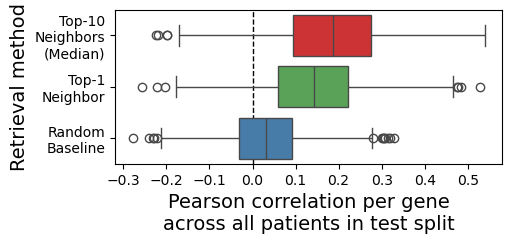

In [8]:
plt.figure(figsize=(5, 2))
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, zorder=0)
sns.boxplot(data=pd.DataFrame({
    'Top-10\nNeighbors\n(Median)': expr_retr_k10.corrwith(expr[expr_retr_k10.columns], axis=1, method='pearson'),
    'Top-1\nNeighbor': expr_retr_k1.corrwith(expr[expr_retr_k1.columns], axis=1, method='pearson'),
    'Random\nBaseline': expr_retr_rand.corrwith(expr[expr_retr_rand.columns], axis=1, method='pearson')
}), palette=[sns.color_palette("Set1")[i] for i in [0, 2, 1]], orient="h")
plt.xlabel('Pearson correlation per gene\nacross all patients in test split', fontsize=14)
plt.ylabel('Retrieval method', fontsize=14)
plt.savefig('corr.pdf', format='pdf', bbox_inches='tight')
plt.show()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


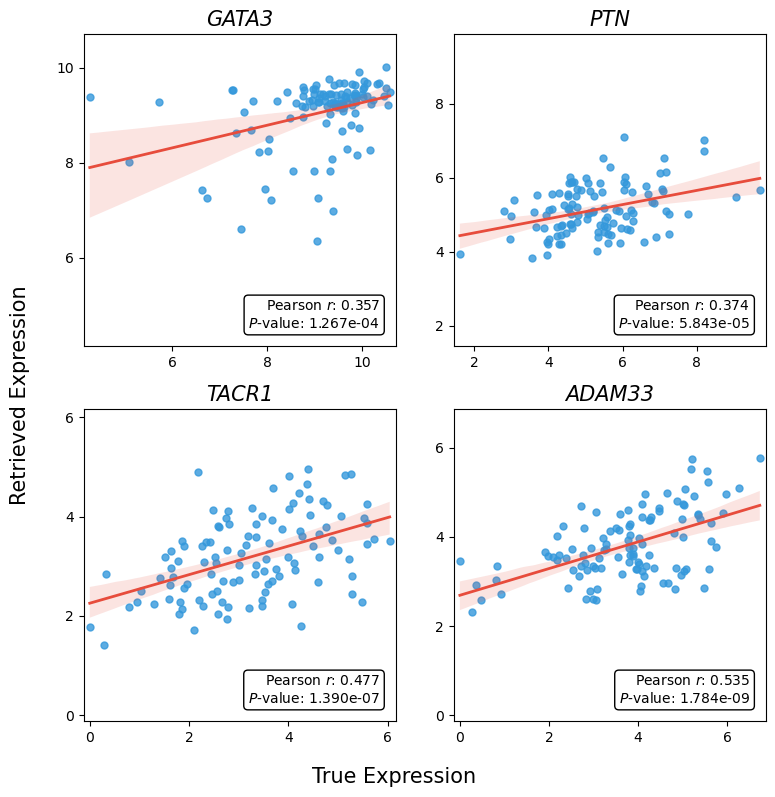

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

def sctrplt(g, ax):
    # True Expression
    x = np.array(expr[expr_retr_k10.columns].loc[genes.loc[genes['Hugo_Symbol'] == g].index]).squeeze()

    # Retrieved Expression
    y = np.array(expr_retr_k10.loc[genes.loc[genes['Hugo_Symbol'] == g].index]).squeeze()

    # Calculate statistics
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    pearson_r, pearson_p = stats.pearsonr(x, y)

    # Plot
    sns.regplot(x=x, y=y, 
                scatter_kws={'s': 25, 'alpha': 0.8, 'color': '#3498db'}, 
                line_kws={'color': '#e74c3c', 'lw': 2, 'label': 'Best Fit'},
                ci=95, ax=ax)

    # --- UPDATED: 20% Buffer Logic ---
    all_data = np.concatenate([x, y])
    d_min = all_data.min()
    d_max = all_data.max()
    d_range = d_max - d_min
    
    # Calculate the 20% offset
    offset = d_range * 0.02
    
    xmin = d_min - offset
    xmax = d_max + offset
    ax_limit = [xmin, xmax]
    # ---------------------------------

    ax.set_xlim(ax_limit)
    ax.set_ylim(ax_limit)

    # Dynamic tick generation (aiming for roughly 5 ticks)
    # Using MaxNLocator is often cleaner for dynamic ranges
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    ax.set_aspect('equal', adjustable='box')

    stats_label = (f"Pearson $r$: {pearson_r:.3f}\n"
                   f"$P$-value: {pearson_p:.3e}")

    ax.text(0.95, 0.05, stats_label, transform=ax.transAxes,
                fontsize=10, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=1))

    ax.set_title(g, fontstyle='italic', fontsize = 15)
    # ax.set_xlabel('True Expression')
    # ax.set_ylabel('Retrieved Expression')
    # ax.grid(True, linestyle=':', alpha=0.6)

# Setup figure
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

sctrplt("GATA3", axs[0, 0])
sctrplt("PTN", axs[0, 1])
sctrplt("TACR1", axs[1, 0])
sctrplt("ADAM33", axs[1, 1])

fig.supxlabel('True Expression', fontsize = 15)
fig.supylabel('Retrieved Expression', fontsize = 15)

plt.tight_layout()
plt.savefig('expr.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [10]:
################ pathway analysis #########################################

import torch.nn.functional as F
import gseapy as gp

sim = F.normalize(all_data["test_img_emb"], dim=1) @ F.normalize(all_data["dev_expr_emb"], dim=1).T
top1_expr, top1_indices = sim.max(dim=1)
top_1_retrieve = [all_data["dev_expr"][i] for i in top1_indices.tolist()]
patient_id_retrieve = [all_data["dev_pid"][i] for i in top1_indices.tolist()]
patient_id_ground_truth = all_data["test_pid"]


expr = pd.read_csv(os.path.join(PROJECT_DIR, "data", "data_mrna_seq_v2_rsem.txt"), sep="\t")
expr = expr.drop(columns=['Entrez_Gene_Id'])
expr = expr.dropna(subset=['Hugo_Symbol'])


col_map = {c[:12]: c for c in expr.columns if c != 'Hugo_Symbol'}
retrieved_expr = expr[['Hugo_Symbol'] + [col_map[pid] for pid in patient_id_retrieve if pid in col_map]]
ground_truth_exp = expr[['Hugo_Symbol'] + [col_map[pid] for pid in patient_id_ground_truth if pid in col_map]]
retrieved_expr.columns = ['Hugo_Symbol'] + patient_id_ground_truth


ground_truth_exp = ground_truth_exp.set_index("Hugo_Symbol")
retrieved_expr = retrieved_expr.set_index("Hugo_Symbol")
gene_sets = os.path.join(PROJECT_DIR, "data", "MSigDB_H.gmt")

def compute_ssgsea(expr_df, gene_sets):
    ss = gp.ssgsea(
        data=expr_df,   # gseapy expects genes × samples
        gene_sets=gene_sets,
        sample_norm_method='rank',
        outdir=None,   # do not write files
        no_plot=True
    )
    
    return ss.res2d

true_pathways = compute_ssgsea(ground_truth_exp, gene_sets)
true_pathways = true_pathways.pivot(
    index="Term",     # gene sets
    columns="Name",   # samples
    values="NES"      # enrichment score
)


retrieve_pathway = compute_ssgsea(retrieved_expr, gene_sets)
retrieve_pathway = retrieve_pathway.pivot(
    index="Term",     # gene sets
    columns="Name",   # samples
    values="NES"      # enrichment score
)

2026-05-15 09:13:28,911 [WARNING] Found duplicated gene names, values averaged by gene names!
2026-05-15 09:13:30,289 [WARNING] Found duplicated gene names, values averaged by gene names!


In [11]:
from scipy.stats import pearsonr
corrs = []
pvals = []
for i in range(len(true_pathways)):
    c, p = pearsonr(true_pathways.iloc[i].tolist(), retrieve_pathway.iloc[i].tolist())
    corrs.append(c)
    pvals.append(p)
print(corrs)

[0.3507615967841453, 0.07296690551666965, 0.19049397497097065, 0.11775406856934127, 0.28995666996545566, 0.08105024853098053, 0.03970097700961515, 0.31649544499780824, 0.19949897737488764, 0.2868638037722973, 0.059653330758713666, 0.16665566199433468, 0.3272279122508631, 0.2216761756968298, 0.30709203340476365, 0.1999726804254734, 0.18628393234417093, 0.3426485063622754, 0.390571620769282, -0.0891141013830802, 0.3220089762498751, 0.19516718829909047, 0.13024821861836186, 0.07556369652356443, 0.08709748157227587, -0.041514387236908236, 0.03671672101815198, 0.319625076994392, 0.15914595373233192, 0.1389478920546674, 0.4389944420859576, 0.2880704001128035, 0.3513772954912815, 0.32330326397182513, 0.1986914900709939, 0.026128381583510357, 0.2571335849325116, 0.10354720036985, 0.16487083714283243, -0.0023573380829898342, 0.3343500813660012, 0.08075694843526905, 0.3068779655736437, 0.015754473735002356, 0.1897130488544118, 0.22362245516490542, 0.0449276531589593, 0.26459635741212445, 0.21728

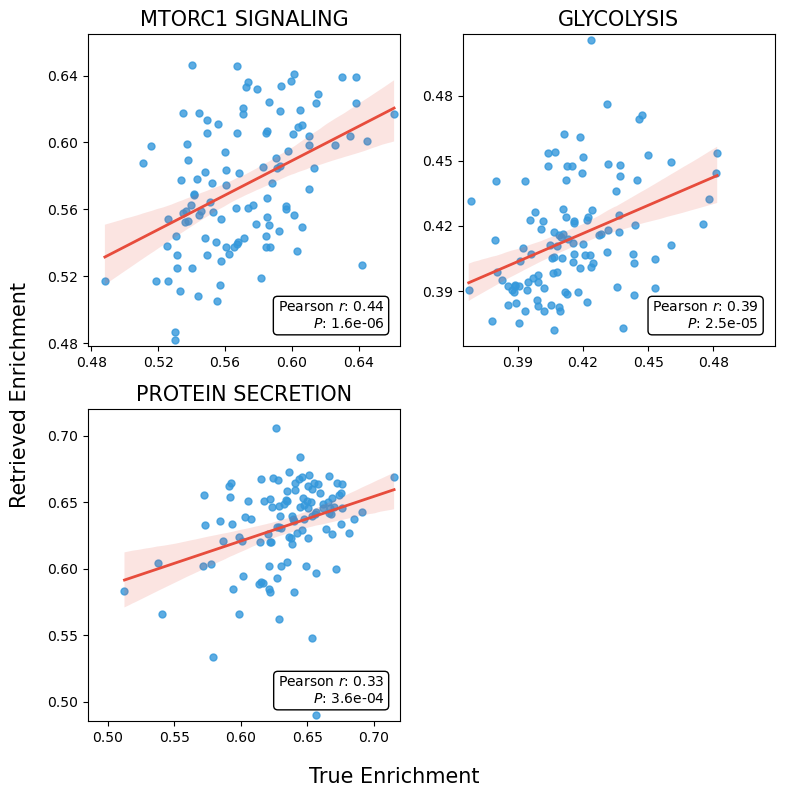

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr
import math

selected_pathways = ['HALLMARK_MTORC1_SIGNALING',
                     'HALLMARK_GLYCOLYSIS',
                     'HALLMARK_PROTEIN_SECRETION']

# 1. Setup the grid dimensions
rows = 2
n_plots = len(selected_pathways)
cols = math.ceil(n_plots / rows)

fig, axes = plt.subplots(rows, cols, figsize=(8, 8)) 
axes_flat = axes.flatten()

# 2. Iterate through the first 50 pathways
for i in range(n_plots):
    ax = axes_flat[i]
    # pathway = true_pathways.index[i]
    pathway = selected_pathways[i]

    x = true_pathways.loc[pathway].astype(float).values
    y = retrieve_pathway.loc[pathway].astype(float).values

    # --- UPDATED: Calculate 20% Buffer Range ---
    combined_data = np.concatenate([x, y])
    data_min = np.min(combined_data)
    data_max = np.max(combined_data)
    
    # Calculate the actual range and the 20% offset
    data_range = data_max - data_min
    offset = data_range * 0.02
    
    # Set identical limits for both axes with the calculated buffer
    axis_min = data_min - offset
    axis_max = data_max + offset
    # -------------------------------------------

    # Calculate stats
    c, p = pearsonr(x, y)

    # Plot
    sns.regplot(x=x, y=y, ci=95, ax=ax,
                scatter_kws={'alpha': 0.8, 's': 25, 'color': "#3498db"}, 
                line_kws={'color': '#e74c3c', 'lw': 2})

    # Stats Text
    stats_text = f"Pearson $r$: {c:.2f}\n$P$: {p:.1e}"
    ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=1))

    # Formatting
    ax.set_title(pathway.replace('HALLMARK_', '').replace('_', ' '), fontsize = 15)

    # ax.set_xlabel("True Enrichment")
    # ax.set_ylabel("Retrieved Enrichment")


    # Apply the unified limits
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)


    # Dynamic tick generation (aiming for roughly 5 ticks)
    # Using MaxNLocator is often cleaner for dynamic ranges
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    ax.set_aspect('equal', adjustable='box')


fig.supxlabel('True Enrichment', fontsize = 15)
fig.supylabel('Retrieved Enrichment', fontsize = 15)

# 3. Clean up
for i in range(n_plots, rows * cols):
    axes_flat[i].axis('off')

plt.tight_layout()
plt.savefig("correlations-for-pathway-enrichment-analysis.pdf", format="pdf")
plt.show()

In [13]:
corrs = []
pvals = []
for i in range(len(true_pathways)):
    c, p = pearsonr(true_pathways.iloc[i].tolist(), retrieve_pathway.iloc[i].tolist())
    corrs.append(c)
    pvals.append(p)
print(corrs)


[0.3507615967841453, 0.07296690551666965, 0.19049397497097065, 0.11775406856934127, 0.28995666996545566, 0.08105024853098053, 0.03970097700961515, 0.31649544499780824, 0.19949897737488764, 0.2868638037722973, 0.059653330758713666, 0.16665566199433468, 0.3272279122508631, 0.2216761756968298, 0.30709203340476365, 0.1999726804254734, 0.18628393234417093, 0.3426485063622754, 0.390571620769282, -0.0891141013830802, 0.3220089762498751, 0.19516718829909047, 0.13024821861836186, 0.07556369652356443, 0.08709748157227587, -0.041514387236908236, 0.03671672101815198, 0.319625076994392, 0.15914595373233192, 0.1389478920546674, 0.4389944420859576, 0.2880704001128035, 0.3513772954912815, 0.32330326397182513, 0.1986914900709939, 0.026128381583510357, 0.2571335849325116, 0.10354720036985, 0.16487083714283243, -0.0023573380829898342, 0.3343500813660012, 0.08075694843526905, 0.3068779655736437, 0.015754473735002356, 0.1897130488544118, 0.22362245516490542, 0.0449276531589593, 0.26459635741212445, 0.21728

In [ ]:


# 'HALLMARK_MTORC1_SIGNALING',
# 'HALLMARK_GLYCOLYSIS',
# 'HALLMARK_PROTEIN_SECRETION'

[30, 18, 40]

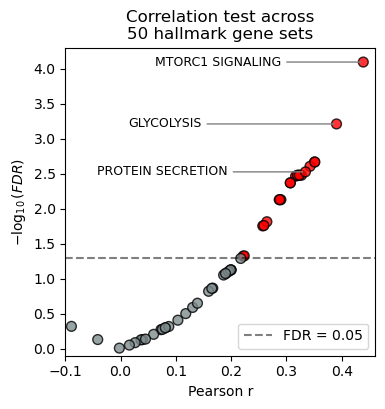

In [73]:
import matplotlib.pyplot as plt
import numpy as np

def plot_volcano(corr, pval, indices, labels):

    fdr = stats.false_discovery_control(pval)

    # Convert to numpy arrays
    corr = np.atleast_1d(corr)
    fdr = np.atleast_1d(fdr)
    # Calculate Y values
    neg_log_fdr = -np.log10(fdr)
    # Create the figure and an "ax" (axis) object
    fig, ax = plt.subplots(figsize=(4, 4))
    # Define threshold
    threshold = -np.log10(0.05)
    colors = ['red' if p > threshold else '#7f8c8d' for p in neg_log_fdr]
    # Plot using the 'ax' object
    ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.5, label='FDR = 0.05')
    ax.scatter(corr, neg_log_fdr, c=colors, alpha=0.8, edgecolors='black', s=50)
    
    
    # --- ANNOTATION LOGIC ---
    if indices is not None and labels is not None:
        for i, label in zip(indices, labels):
            x = corr[i]
            y = neg_log_fdr[i]
            
            # Annotate with a small offset and a pointer arrow
            ax.annotate(
                label.replace('HALLMARK_', '').replace('_', ' '),
                xy=(x, y),
                xytext=(-150, 0),          # 5 points offset from the dot
                textcoords='offset points',
                fontsize=9,
                va='center',
                # bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='gray'),
                arrowprops=dict(
                    arrowstyle='-',    # Simple arrow head
                    color='grey',
                    lw=1                # Line width
                )
            )
    # ------------------------
    
    # --- SET LIMITS USING THE AX OBJECT ---
    ax.set_xlim([-0.1, 1.05*max(corr)])
    ax.set_ylim([-0.1, 1.05*max(neg_log_fdr)])
    # --------------------------------------
    ax.set_title('Correlation test across\n50 hallmark gene sets')
    ax.set_xlabel('Pearson r')
    ax.set_ylabel('$-\log_{10}(FDR)$')
    ax.legend()
    plt.savefig("all_corrs.pdf", format="pdf")
    plt.show()

plot_volcano(corrs, pvals, [true_pathways.index.tolist().index(p) for p in selected_pathways], selected_pathways)

<function scipy.stats._morestats.false_discovery_control(ps, *, axis=0, method='bh')>

In [16]:
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

corrs = []
pvals = []
spearman_corrs = []
spearman_pvals = []
pvals = []
pathways = []

# Loop over pathways
for i in range(50):
    pathway = true_pathways.index[i]
    
    x = true_pathways.loc[pathway].astype(float).values
    y = retrieve_pathway.loc[pathway].astype(float).values
    
    c, p = pearsonr(x, y)
    c_spearman, p_spearman = spearmanr(x, y)
    
    pathways.append(pathway)
    corrs.append(c)
    pvals.append(p)

    spearman_corrs.append(c_spearman)
    spearman_pvals.append(p_spearman)

# FDR correction
reject, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')
s_reject, s_pvals_fdr, _, _ = multipletests(spearman_pvals, method='fdr_bh')

# Create DataFrame
results = pd.DataFrame({
    'pathway': pathways,
    'pearson_correlation': corrs,
    'pearson_p_value': pvals,
    'pearson_FDR': pvals_fdr,
    'pearson_significant': reject,
    'spearson_correlation': spearman_corrs,
    'spearson_p_value': spearman_pvals,
    'spearman_FDR': s_pvals_fdr,
    'spearman_significant': s_reject,
    
})

# Optional: sort by FDR (most significant first)
results = results.sort_values('pearson_FDR')
results
# results.to_excel('pathway_correlation_results.xlsx', index=False)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,pathway,pearson_correlation,pearson_p_value,pearson_FDR,pearson_significant,spearson_correlation,spearson_p_value,spearman_FDR,spearman_significant
30,HALLMARK_MTORC1_SIGNALING,0.438994,0.000002,0.000080,True,0.434662,0.000002,0.000097,True
18,HALLMARK_GLYCOLYSIS,0.390572,0.000025,0.000615,True,0.424185,0.000004,0.000097,True
0,HALLMARK_ADIPOGENESIS,0.350762,0.000172,0.002151,True,0.289754,0.002138,0.009281,True
32,HALLMARK_MYC_TARGETS_V2,0.351377,0.000167,0.002151,True,0.337353,0.000313,0.002611,True
17,HALLMARK_G2M_CHECKPOINT,0.342649,0.000248,0.002481,True,0.341167,0.000265,0.002611,True
40,HALLMARK_PROTEIN_SECRETION,0.334350,0.000357,0.002975,True,0.332137,0.000393,0.002806,True
33,HALLMARK_MYOGENESIS,0.323303,0.000571,0.003324,True,0.304992,0.001196,0.005981,True
27,HALLMARK_KRAS_SIGNALING_DN,0.319625,0.000665,0.003324,True,0.341397,0.000262,0.002611,True
12,HALLMARK_E2F_TARGETS,0.327228,0.000484,0.003324,True,0.327390,0.000481,0.003005,True
20,HALLMARK_HEME_METABOLISM,0.322009,0.000602,0.003324,True,0.316966,0.000741,0.004118,True


In [17]:
from scipy.stats import spearmanr

corrs_s = []
pvals_s = []

for i in range(len(true_pathways)):
    # Use .iloc[i] to ensure you are moving through each row
    x = true_pathways.iloc[i].astype(float).values
    y = retrieve_pathway.iloc[i].astype(float).values
    
    # Calculate Spearman
    c, p = spearmanr(x, y)
    
    corrs_s.append(c)
    pvals_s.append(p)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [14]:
classes = ['LumA', 'LumB', 'Basal']#, 'Her2', 'Normal']

def clear_missing_data(X1, X2, X3, y, pid, classes):
    rm_indices = [i for i, v in enumerate(y) if v not in classes]
    y = [o for o in y if o in classes]
    X1 = np.delete(X1, rm_indices, axis=0)
    X2 = np.delete(X2, rm_indices, axis=0)
    pid = [pid[i] for i in range(len(pid)) if i not in rm_indices]
    return X1, X2, X3, y, pid

lrData = {
    f'{var}_{k}': val 
    for k in ['dev', 'test'] 
    for var, val in zip(['X1', 'X2', 'X3', 'y', 'pid'], clear_missing_data(
        X1 = all_data[f'{k}_img_emb'].numpy(), 
        X2 = all_data[f'{k}_img'].numpy(), 
        X3 = all_data[f'{k}_expr'].numpy(), 
        y = [pid2subtype.get(p, np.nan) for p in all_data[f'{k}_pid']], 
        pid = all_data[f'{k}_pid'], 
        classes = classes
    ))
}

# sanity check
assert lrData['X1_dev'].shape[0] == len(lrData['y_dev'])
assert lrData['X1_test'].shape[0] == len(lrData['y_test'])
assert lrData['y_dev'] == [pid2subtype[p] for p in lrData['pid_dev']]
assert lrData['y_test'] == [pid2subtype[p] for p in lrData['pid_test']]

In [ ]:
def fitLogReg(X, y):
    stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=8754)
    model = LogisticRegressionCV(
        cv=stratified_cv,  
        solver='saga',      
        l1_ratios=[0.5], 
        max_iter=10000,
        random_state=42,
        use_legacy_attributes=False
    )
    model.fit(X, y)
    return model

In [ ]:
m1 = fitLogReg(lrData['X1_dev'], lrData['y_dev'])

In [716]:
report1 = classification_report(lrData['y_test'], m1.predict(lrData['X1_test']), labels=classes, zero_division=0, output_dict=True)

In [ ]:
preprocessor = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=128))
])
lrData['X2_dev_pca'] = preprocessor.fit_transform(lrData['X2_dev'])
lrData['X2_test_pca'] = preprocessor.transform(lrData['X2_test'])

m2 = fitLogReg(lrData['X2_dev_pca'], lrData['y_dev'])

In [734]:
report2 = classification_report(lrData['y_test'], m2.predict(lrData['X2_test_pca']), labels=classes, zero_division=0, output_dict=True)